Generación, limpieza y transformación de un DataSet el principio GIGO
Fecha: 28 de mayo del 2026
Autor: Fernanda Pacheco Banda

Objetivo general
identificar problemas de calidad de datos,aplicar técnicas de limpieza y transformación, y analizar cómo los datos incorrectos afectan el análisis y los modelos de Machine Learning mediante el principio GIGO.

Actividad
Identifique y documente:

Valores nulos
Outliers (Negativos o fuera de rango)
Datos inválidos
Facturas canceladas ( identificadas con la letra c)
Duplicados
Problemas de formato o tipo de datos (Fechas o Monto)
Posteriormente:

Limpie el dataset
Transforme los datos
Justifique las decisiones tomadas
Explique cómo afecta el principio GIGO al análisis de datos y Machine Learning

Graficas solicitadas para la identificación de anomalias
Ventas por pais
Heatmap de valores nulos
Distribución del monto

In [1]:
#Importar librerias

In [7]:
import pandas as pd

In [8]:
import numpy as np

In [9]:
import matplotlib.pyplot as plt

In [10]:
import seaborn as sns

In [11]:
#Cargar archivo CSV
df = pd.read_csv("ventas-por-factura.csv")

In [12]:
#Mostrar el numero de filas y columnas del DataFrame
df.shape

(25953, 6)

In [10]:
#Mostrar las primeras 5 filas
df.head()

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
0,548370,3/30/2021 16:14:00,15528.0,United Kingdom,123,"229,33"
1,575767,11/11/2021 11:11:00,17348.0,United Kingdom,163,"209,73"
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,"-1,45"
3,549106,4/6/2021 12:08:00,17045.0,United Kingdom,1,"39,95"
4,573112,10/27/2021 15:33:00,16416.0,United Kingdom,357,"344,83"


In [11]:
#Mostrar las ultimas 5 filas
df.tail()

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
25948,C556518,6/13/2021 10:53:00,16794.0,United Kingdom,-2,"-12,70"
25949,553060,5/13/2021 10:44:00,15826.0,United Kingdom,488,"720,00"
25950,577049,11/17/2021 13:58:00,17397.0,United Kingdom,104,"298,78"
25951,550122,4/14/2021 12:39:00,12931.0,United Kingdom,1176,"1488,00"
25952,537999,12/9/2020 11:44:00,NaN,United Kingdom,-223,"0,00"


In [12]:
#Generar estadisticas de las columnas
df.describe()

,ID Cliente,Cantidad
count,22229.000000,25953.000000
mean,15238.289892,199.474049
std,1732.981685,1107.075809
min,12346.000000,-80995.000000
25%,13755.000000,6.000000
50%,15136.000000,100.000000
75%,16746.000000,240.000000
max,18287.000000,80995.000000


In [13]:
#Crea una copia del dataFrame original
dfCopy = df.copy()

In [16]:
#Mostrar informacion general del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25953 entries, 0 to 25952
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   N° de factura     25953 non-null  object 
 1   Fecha de factura  25953 non-null  object 
 2   ID Cliente        22229 non-null  float64
 3   País              25953 non-null  object 
 4   Cantidad          25953 non-null  int64  
 5   Monto             25953 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 1.2+ MB


In [17]:
#Hacer conteo de valores nulos por columna
df.isnull().sum()

N° de factura          0
Fecha de factura       0
ID Cliente          3724
País                   0
Cantidad               0
Monto                  0
dtype: int64

In [18]:
#Calcular porcentaje de valores faltantes
(df.isnull().sum()/len(df))*100

N° de factura        0.000000
Fecha de factura     0.000000
ID Cliente          14.349016
País                 0.000000
Cantidad             0.000000
Monto                0.000000
dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

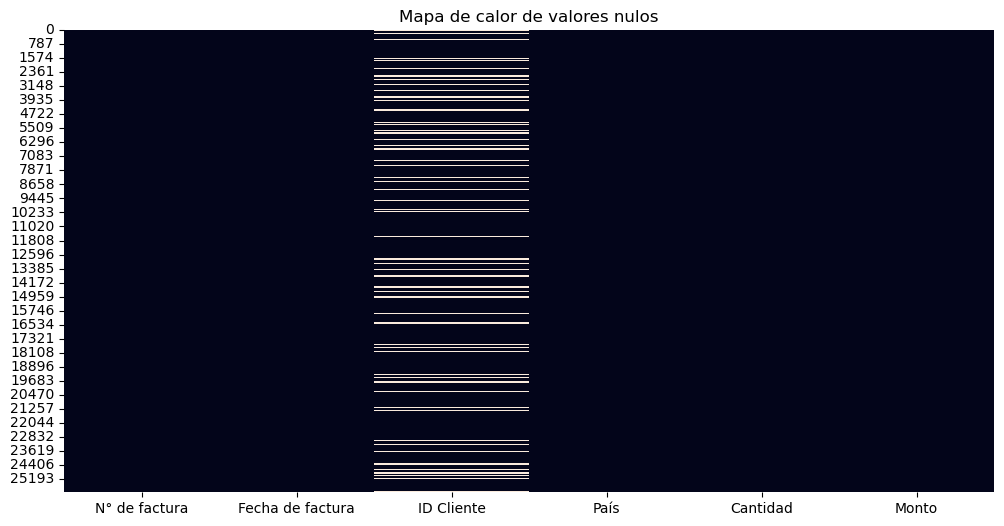

In [25]:
#GRAFICA DE VALORES NULOS
#Define el tamano de la grafica
plt.figure(figsize = (10,6))
#Crea un mapa de calor para ver valores nulos
sns.heatmap(df.isnull(),cbar = False)
#Agrega titulo a la grafica
plt.title("Mapa de calor de valores nulos")
#Muestra la grafica
plt.show

In [26]:
#DETECCION DE DUPLICADOS
#Contar registros duplicados existentes
df.duplicated().sum()

np.int64(0)

In [21]:
#Eliminar registros duplicados
df.drop_duplicates(inplace = True)

In [22]:
df.duplicated().sum()

np.int64(0)

In [31]:
#IDENTIFICACIONES DE FACTURAS CANCELADAS
# Facturas canceladas identificadas con la letra C
facturas_canceladas = df[df['N° de factura'].astype(str).str.startswith('C')]

In [32]:
# Mostrar primeras facturas canceladas
facturas_canceladas.head()

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,"-1,45"
10,C543628,2/10/2021 15:51:00,16558.0,United Kingdom,-5,"-9,25"
17,C553508,5/17/2021 13:44:00,14000.0,United Kingdom,-3,"-1,95"
20,C577693,11/21/2021 11:48:00,12628.0,Germany,-3,"-16,85"
22,C547309,3/22/2021 11:17:00,17416.0,United Kingdom,-12,"-45,00"


In [33]:
# Cantidad de facturas canceladas
len(facturas_canceladas)

3837

In [34]:
# DETECCIÓN DE DATOS INVÁLIDOS
# Cantidades negativas o iguales a cero
df[df['Cantidad'] <= 0]

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,"-1,45"
10,C543628,2/10/2021 15:51:00,16558.0,United Kingdom,-5,"-9,25"
16,542418,1/27/2021 17:39:00,NaN,United Kingdom,-17,"0,00"
17,C553508,5/17/2021 13:44:00,14000.0,United Kingdom,-3,"-1,95"
20,C577693,11/21/2021 11:48:00,12628.0,Germany,-3,"-16,85"
...,...,...,...,...,...,...
25943,C557061,6/16/2021 14:55:00,14895.0,United Kingdom,-5,"-14,75"
25944,C562147,8/3/2021 10:47:00,16180.0,United Kingdom,-7,"-18,35"
25947,C553519,5/17/2021 14:16:00,18218.0,United Kingdom,-2,"-9,90"
25948,C556518,6/13/2021 10:53:00,16794.0,United Kingdom,-2,"-12,70"


In [25]:
# Montos negativos o iguales a cero
# Primero se convierte monto a numérico
df['Monto'] = pd.to_numeric(df['Monto'], errors='coerce')

In [26]:
df = df.dropna(subset=['Monto'])

In [27]:
df['Monto'].dtype

dtype('float64')

In [28]:
# Buscar montos inválidos
df[df['Monto'] <= 0]

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto


In [29]:
# PROBLEMAS DE FORMATO O TIPO DE DATOS
# Verificar tipo de dato de fecha
df['Fecha de factura'].dtype

dtype('O')

In [42]:
# Convertir fecha a formato datetime
df['Fecha de factura'] = pd.to_datetime(df['Fecha de factura'])

In [43]:
# Verificar conversión
df['Fecha de factura'].dtype

dtype('<M8[ns]')

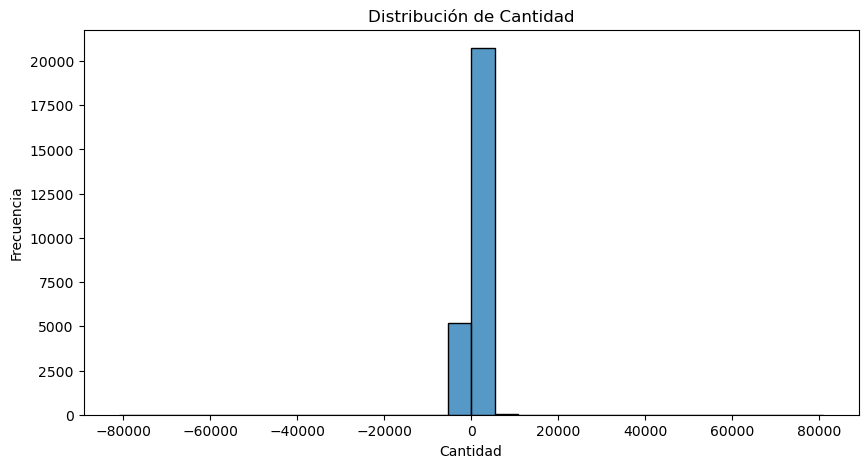

In [15]:
# DETECCIÓN DE OUTLIERS (Valores fuera de rango o anormales)
# Grafico para Cantidad
plt.figure(figsize=(10,5))
sns.histplot(df['Cantidad'])
plt.title("Distribución de Cantidad")
plt.xlabel("Cantidad")
plt.ylabel("Frecuencia")
plt.show()

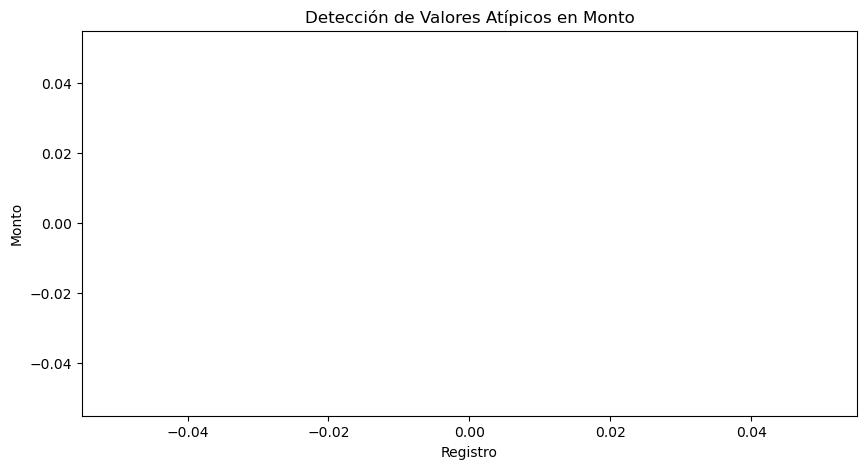

In [30]:
# Grafica para Monto
plt.figure(figsize=(10,5))
sns.histplot(df['Monto'])
plt.title("Detección de Valores Atípicos en Monto")
plt.xlabel("Registro")
plt.ylabel("Monto")
plt.show()

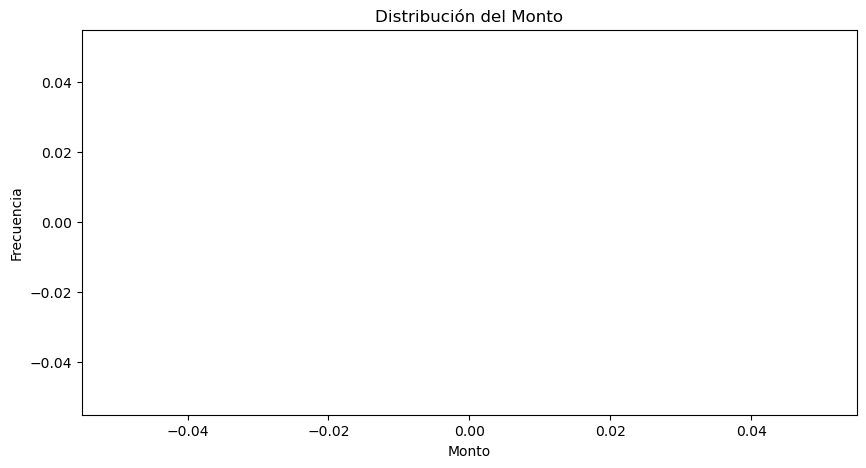

In [31]:
# DISTRIBUCIÓN DEL MONTO
plt.figure(figsize=(10,5))
sns.histplot(df['Monto'])
plt.title("Distribución del Monto")
plt.xlabel("Monto")
plt.ylabel("Frecuencia")
plt.show()

In [32]:
# VENTAS POR PAÍS
# Agrupar ventas por país
ventas_pais = df.groupby('País')['Monto'].sum().sort_values(ascending=False)

In [33]:
# Mostrar top 10 países
ventas_pais = ventas_pais.head(10)

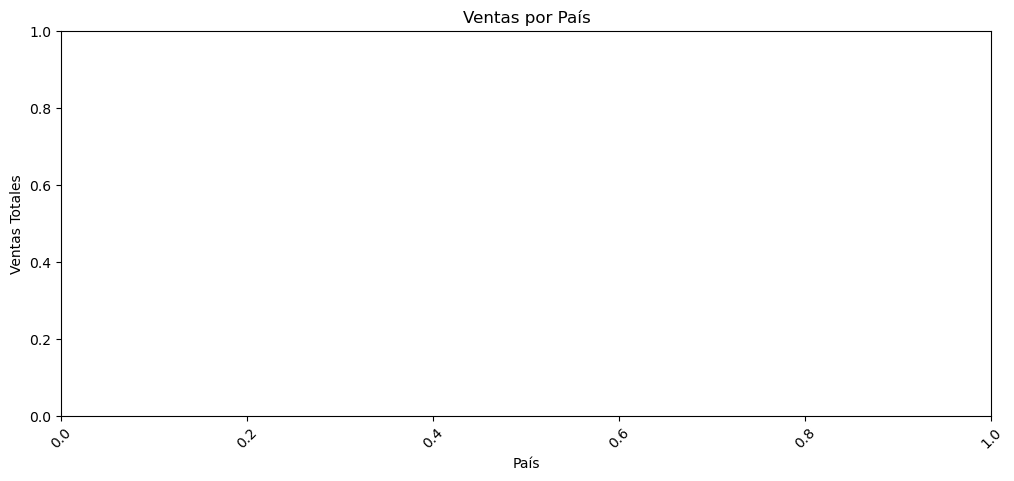

In [34]:
# Graficar
plt.figure(figsize=(12,5))
sns.barplot(x=ventas_pais.index,
            y=ventas_pais.values)
plt.title("Ventas por País")
plt.xlabel("País")
plt.ylabel("Ventas Totales")
plt.xticks(rotation=45)
plt.show()

In [35]:
# LIMPIEZA DEL DATASET
# Eliminar registros duplicados
df.drop_duplicates(inplace=True)

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto


In [36]:
# Eliminar facturas canceladas
df = df[~df['N° de factura'].astype(str).str.startswith('C')]

In [37]:
# Eliminar cantidades negativas o iguales a cero
df = df[df['Cantidad'] > 0]

In [38]:
# Eliminar montos negativos o iguales a cero
df = df[df['Monto'] > 0]

In [39]:
# Eliminar registros nulos en ID Cliente
df.dropna(subset=['ID Cliente'], inplace=True)

In [40]:
# Verificar limpieza
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   N° de factura     0 non-null      object 
 1   Fecha de factura  0 non-null      object 
 2   ID Cliente        0 non-null      float64
 3   País              0 non-null      object 
 4   Cantidad          0 non-null      int64  
 5   Monto             0 non-null      float64
dtypes: float64(2), int64(1), object(3)
memory usage: 0.0+ bytes


In [44]:
# TRANSFORMACIÓN DE DATOS
# Crear columna de año
df['Año'] = df['Fecha de factura'].dt.year

In [45]:
# Crear columna de día
df['Dia'] = df['Fecha de factura'].dt.day

In [46]:
# Mostrar dataframe transformado
df.head()

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto,Año,Dia


# JUSTIFICACIÓN DE LAS DECISIONES

 1. Se eliminaron registros duplicados para evitar análisis repetidos y resultados incorrectos.
 2. Se eliminaron facturas canceladas porque no representan ventas reales dentro del negocio.
 3. Se eliminaron cantidades negativas y montos negativos debido a que representan inconsistencias o errores.
 4. Se eliminaron valores nulos en ID Cliente porque afectan la identificación correcta de clientes.
 5. Se convirtió la fecha al tipo datetime para facilitar análisis temporales.
 6. Se transformaron los datos creando columnas de año, mes y día para mejorar el análisis.

# PRINCIPIO GIGO

 GIGO significa:
 Garbage In, Garbage Out
 Este principio establece que si los datos de entrada contienen errores, inconsistencias o valores inválidos, los resultados obtenidos también serán incorrectos.

 En análisis de datos y Machine Learning,utilizar datos sucios puede provocar:

 - Predicciones incorrectas
 - Modelos poco precisos
 - Análisis erróneos
 - Malas decisiones empresariales

 Por esta razón, la limpieza y transformación de datos es una etapa fundamental antes de cualquier análisis.